# 08 Analiza grešaka — InceptionV3 (fine-tune)

Najbolji model projekta: test accuracy **56.9%**, macro F1 **0.570** (slučajno pogađanje 5.56%).

Sveska 07 je istu analizu radila nad dense glavom (49.9%). Ovde se ponavlja nad finalnim
modelom i dodaje se poređenje — **šta je fine-tuning zapravo popravio, a šta ne**.

**Figure koje ova sveska pravi** (sve u `reports/figures/`):

| Fajl | Sadržaj |
|---|---|
| `transfer_finetune_recall_per_class.png` | recall po klasi |
| `transfer_finetune_vs_dense_recall.png` | promena recall-a fine-tune naspram dense |
| `transfer_finetune_errors.png` | 8 najsigurnijih promašaja |
| `transfer_finetune_confidence.png` | raspodela sigurnosti, tačne vs pogrešne predikcije |

Matrica konfuzije i krive učenja nastaju van sveske — `src/evaluate.py` odnosno
`src/plot_curves.py`, kao `transfer_finetune_confusion.png` i `transfer_finetune_curves.png`.


In [1]:
import json
import os
import sys
from pathlib import Path

ROOT = Path("..").resolve()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dataset import class_names

EXP = Path("experiments/transfer_finetune")
DENSE = Path("experiments/transfer_dense")
FIG = Path("reports/figures")
FIG.mkdir(parents=True, exist_ok=True)

names = class_names()
metrics = json.load(open(EXP / "test_metrics.json"))
print("klasa:", len(names))
print("test accuracy:", round(metrics["test_accuracy"], 4), "| macro F1:", round(metrics["macro_f1"], 4))

I0000 00:00:1788085910.408100  805541 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788085910.502344  805541 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788085912.350853  805541 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


klasa: 18
test accuracy: 0.5691 | macro F1: 0.5704


## 1. Koje su klase lake, a koje teške

Per-class recall iz `classification_report.json` — udeo slika te klase koje je model pogodio.

In [2]:
def per_class_table(exp_dir):
    with open(exp_dir / "classification_report.json") as f:
        report = json.load(f)
    return pd.DataFrame([
        {"klasa": k, "precision": v["precision"], "recall": v["recall"],
         "f1": v["f1-score"], "slika": int(v["support"])}
        for k, v in report.items() if k in names
    ])

per_class = per_class_table(EXP).sort_values("recall", ascending=False).reset_index(drop=True)
per_class

,klasa,precision,recall,f1,slika
0,01_Byzantin_Iconography,0.875000,0.937008,0.904943,127
1,18_PopArt,0.732620,0.815476,0.771831,168
2,02_Early_Renaissance,0.754545,0.741071,0.747748,112
3,14_Cubism,0.681319,0.673913,0.677596,184
4,16_AbstractArt,0.662500,0.666667,0.664577,159
5,04_High_Renaissance,0.561644,0.656000,0.605166,125
6,03_Northern_Renaissance,0.688073,0.609756,0.646552,123
7,15_Surrealism,0.500000,0.596273,0.543909,161
8,09_Impressionism,0.514019,0.582011,0.545906,189
9,06_Rococo,0.537313,0.576000,0.555985,125


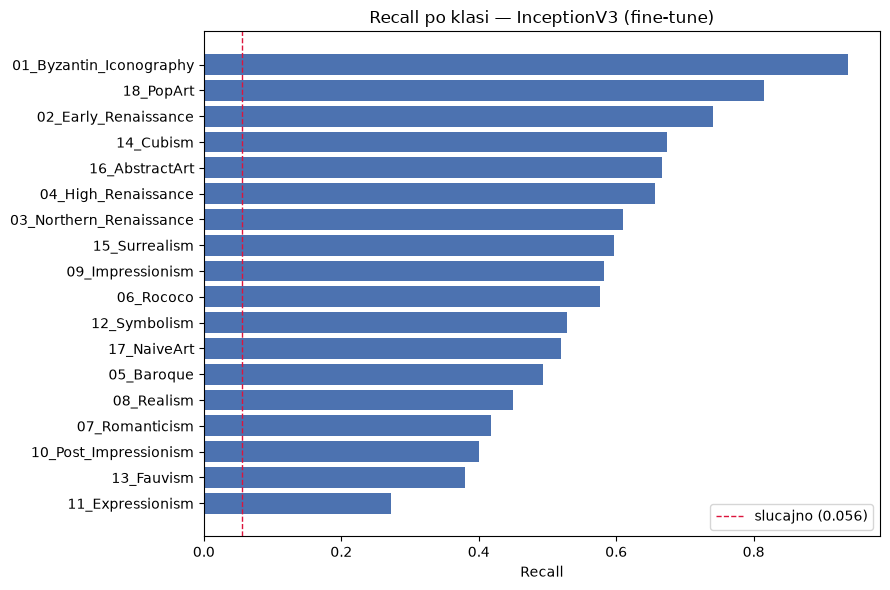

najlakse: 01_Byzantin_Iconography, 18_PopArt, 02_Early_Renaissance
najteze : 10_Post_Impressionism, 13_Fauvism, 11_Expressionism


In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
order = per_class.sort_values("recall")
ax.barh(order["klasa"], order["recall"], color="#4C72B0")
ax.axvline(1 / len(names), color="crimson", linestyle="--", linewidth=1,
           label=f"slucajno ({1/len(names):.3f})")
ax.set_xlabel("Recall")
ax.set_title("Recall po klasi — InceptionV3 (fine-tune)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "transfer_finetune_recall_per_class.png", dpi=150)
plt.show()

print("najlakse:", ", ".join(per_class.head(3)["klasa"]))
print("najteze :", ", ".join(per_class.tail(3)["klasa"]))

## 2. Šta je fine-tuning promenio

Poređenje sa dense glavom, po klasi. Bitno je gledati **i recall i precision**: pad recall-a
uz rast precision-a ne znači da je klasa postala gora, nego da je model prestao da je koristi
kao korpu za neprepoznato.

In [4]:
dense_pc = per_class_table(DENSE).set_index("klasa")
ft_pc = per_class_table(EXP).set_index("klasa")

promena = pd.DataFrame({
    "recall_dense": dense_pc["recall"],
    "recall_finetune": ft_pc["recall"],
    "d_recall": ft_pc["recall"] - dense_pc["recall"],
    "prec_dense": dense_pc["precision"],
    "prec_finetune": ft_pc["precision"],
    "d_precision": ft_pc["precision"] - dense_pc["precision"],
    "d_f1": ft_pc["f1"] - dense_pc["f1"],
}).sort_values("d_recall", ascending=False)

promena.round(3)

,recall_dense,recall_finetune,d_recall,prec_dense,prec_finetune,d_precision,d_f1
klasa,,,,,,,
15_Surrealism,0.366,0.596,0.230,0.500,0.500,0.000,0.121
05_Baroque,0.291,0.493,0.203,0.457,0.465,0.008,0.123
10_Post_Impressionism,0.229,0.401,0.172,0.352,0.403,0.051,0.124
18_PopArt,0.696,0.815,0.119,0.696,0.733,0.036,0.075
07_Romanticism,0.306,0.418,0.112,0.350,0.400,0.050,0.082
08_Realism,0.344,0.450,0.106,0.446,0.474,0.028,0.073
16_AbstractArt,0.579,0.667,0.088,0.594,0.662,0.069,0.079
01_Byzantin_Iconography,0.850,0.937,0.087,0.885,0.875,-0.010,0.037
02_Early_Renaissance,0.670,0.741,0.071,0.586,0.755,0.169,0.123


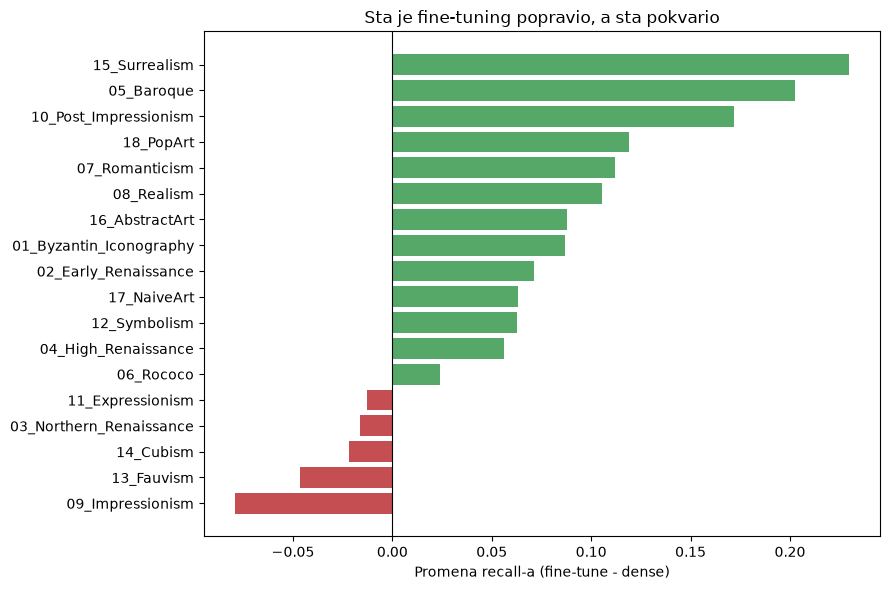

popravljeno: 13 klasa
pogorsano  : 5 klasa

klase kojima recall pada, ali precision raste (model prestao da ih pretrpava):
                         d_recall  d_precision   d_f1
klasa                                                
11_Expressionism           -0.013        0.023  0.000
03_Northern_Renaissance    -0.016        0.164  0.076
14_Cubism                  -0.022        0.091  0.039
13_Fauvism                 -0.046        0.106  0.026
09_Impressionism           -0.079        0.120  0.052


In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
order = promena.sort_values("d_recall")
boje = ["#C44E52" if v < 0 else "#55A868" for v in order["d_recall"]]
ax.barh(order.index, order["d_recall"], color=boje)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Promena recall-a (fine-tune - dense)")
ax.set_title("Sta je fine-tuning popravio, a sta pokvario")
fig.tight_layout()
fig.savefig(FIG / "transfer_finetune_vs_dense_recall.png", dpi=150)
plt.show()

print("popravljeno:", int((promena["d_recall"] > 0).sum()), "klasa")
print("pogorsano  :", int((promena["d_recall"] < 0).sum()), "klasa")
print()
print("klase kojima recall pada, ali precision raste (model prestao da ih pretrpava):")
print(promena[(promena["d_recall"] < 0) & (promena["d_precision"] > 0)][["d_recall", "d_precision", "d_f1"]].round(3))

## 3. Najčešće zamene

Najveće vrednosti van dijagonale matrice konfuzije — parovi koje model meša.

In [6]:
cm = np.loadtxt(EXP / "confusion_matrix.csv", delimiter=",", dtype=int)

pairs = [
    {"tacna": names[i], "predvidjena": names[j], "slika": int(cm[i, j]),
     "udeo u klasi": cm[i, j] / cm[i].sum()}
    for i in range(len(names)) for j in range(len(names)) if i != j and cm[i, j] > 0
]
top_confusions = (
    pd.DataFrame(pairs).sort_values("slika", ascending=False).head(10).reset_index(drop=True)
)
top_confusions

,tacna,predvidjena,slika,udeo u klasi
0,13_Fauvism,10_Post_Impressionism,29,0.268519
1,05_Baroque,06_Rococo,28,0.189189
2,10_Post_Impressionism,09_Impressionism,28,0.145833
3,08_Realism,09_Impressionism,27,0.150000
4,07_Romanticism,05_Baroque,26,0.194030
5,06_Rococo,05_Baroque,24,0.192000
6,09_Impressionism,10_Post_Impressionism,24,0.126984
7,09_Impressionism,08_Realism,23,0.121693
8,08_Realism,07_Romanticism,21,0.116667
9,17_NaiveArt,15_Surrealism,20,0.126582


In [7]:
# da li su zamene izmedju susednih pokreta? klase su numerisane hronoloski,
# pa je razlika indeksa gruba mera istorijske udaljenosti
idx = {n: i for i, n in enumerate(names)}
tc = top_confusions.copy()
tc["razmak"] = (tc["predvidjena"].map(idx) - tc["tacna"].map(idx)).abs()

print("prosecan razmak kod 10 najcescih zamena:", round(tc["razmak"].mean(), 2))
print("susedni pokreti (razmak 1):", int((tc["razmak"] == 1).sum()), "od 10")
tc[["tacna", "predvidjena", "slika", "razmak"]]

prosecan razmak kod 10 najcescih zamena: 1.4
susedni pokreti (razmak 1): 7 od 10


,tacna,predvidjena,slika,razmak
0,13_Fauvism,10_Post_Impressionism,29,3
1,05_Baroque,06_Rococo,28,1
2,10_Post_Impressionism,09_Impressionism,28,1
3,08_Realism,09_Impressionism,27,1
4,07_Romanticism,05_Baroque,26,2
5,06_Rococo,05_Baroque,24,1
6,09_Impressionism,10_Post_Impressionism,24,1
7,09_Impressionism,08_Realism,23,1
8,08_Realism,07_Romanticism,21,1
9,17_NaiveArt,15_Surrealism,20,2


**Za diskusiju:** zamene između istorijski susednih pokreta su očekivane i za čoveka sporne;
zamene između udaljenih pokreta ukazuju na stvarnu slabost modela.

## 4. Konkretni promašaji

Za razliku od dense faze, ovde **nema keširanih feature-a** — baza se menjala tokom treninga,
pa se predikcije moraju računati propuštanjem test slika kroz ceo sačuvani model.

Test generator ide sa `shuffle=False`, pa se redosled predikcija poklapa sa `test_iter.classes`
i `test_iter.filepaths`.

In [8]:
from tensorflow import keras
from dataset import make_generators

image_size = json.load(open(EXP / "run_config.json"))["image_size"]
_, _, test_iter, _ = make_generators(image_size=image_size, batch_size=32)

model = keras.models.load_model(EXP / "best.keras")
probs = model.predict(test_iter, verbose=1)

y_pred = probs.argmax(axis=1)
y_true = np.asarray(test_iter.classes)
confidence = probs.max(axis=1)

print("test accuracy (provera):", round(float((y_pred == y_true).mean()), 4))
print("iz test_metrics.json   :", round(metrics["test_accuracy"], 4))

Found 12626 validated image filenames belonging to 18 classes.


Found 2706 validated image filenames belonging to 18 classes.


Found 2706 validated image filenames belonging to 18 classes.


I0000 00:00:1788085914.875312  805541 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA RTX A500 Laptop GPU, pci bus id: 0000:03:00.0, compute capability: 8.6


I0000 00:00:1788085978.238010  805541 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


...

84/85 [============================>.] - ETA: 0s

W0000 00:00:1788086000.119169  805687 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.45GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


85/85 [==============================] - ETA: 0s

85/85 [==============================] - 27s 240ms/step


test accuracy (provera): 0.5687
iz test_metrics.json   : 0.5691


In [9]:
def autor_i_delo(path):
    """Izvlaci autora i naziv dela iz putanje Pandora_18k/<klasa>/<Autor>/<naziv>.jpg.

    Skup imenuje foldere nedosledno ("Rosseau Henry", "andre-derain", "Artists"),
    a nazivi dela ponekad ponavljaju ime autora ili su samo redni broj.
    """
    autor = Path(path).parent.name.replace("_", " ").replace("-", " ").strip()
    if autor.islower():
        autor = autor.title()

    delo = Path(path).stem.replace("_", " ").replace("-", " ").strip()

    # skloni ime autora sa pocetka naziva dela, da se ne ponavlja u naslovu
    reci = autor.lower().split()
    tokeni = delo.split()
    while tokeni and tokeni[0].lower() in reci:
        tokeni.pop(0)
    delo = " ".join(tokeni).strip()

    if not delo or delo.isdigit():
        delo = "(bez naziva)"
    return autor, delo

meta = [autor_i_delo(f) for f in test_iter.filepaths]

errors = pd.DataFrame({
    "filepath": test_iter.filepaths,
    "autor": [a for a, _ in meta],
    "delo": [d for _, d in meta],
    "tacna": [names[i] for i in y_true],
    "predvidjena": [names[i] for i in y_pred],
    "sigurnost": confidence,
})
errors = errors[errors["tacna"] != errors["predvidjena"]]

print(f"pogresnih: {len(errors)} od {len(y_true)}")
# najsigurnije greske su najzanimljivije - model je ubedjen a promasio je
errors.sort_values("sigurnost", ascending=False).head(10)[
    ["autor", "delo", "tacna", "predvidjena", "sigurnost"]
].reset_index(drop=True)

pogresnih: 1167 od 2706


,autor,delo,tacna,predvidjena,sigurnost
0,Kandinsky Vassily,succession 1935,16_AbstractArt,18_PopArt,0.999974
1,Rosseau Henry,the sleeping gypsy 1897,17_NaiveArt,15_Surrealism,0.997391
2,Artists,(bez naziva),07_Romanticism,06_Rococo,0.995703
3,Sironi Mario,the plane,14_Cubism,16_AbstractArt,0.995618
4,Andre Derain,still life with pears and indian bowl,10_Post_Impressionism,14_Cubism,0.995454
5,Louis Schanker,abstraction,16_AbstractArt,14_Cubism,0.995381
6,Oscar Dominguez,(bez naziva),14_Cubism,15_Surrealism,0.994967
7,Valtat Louis,xx Woman with Grapes 1900 xx Private collection,13_Fauvism,09_Impressionism,0.993606
8,Kahlo Frieda,memory the heart 1937,15_Surrealism,17_NaiveArt,0.991244
9,Klee Paul,senecio 19221,14_Cubism,16_AbstractArt,0.990393


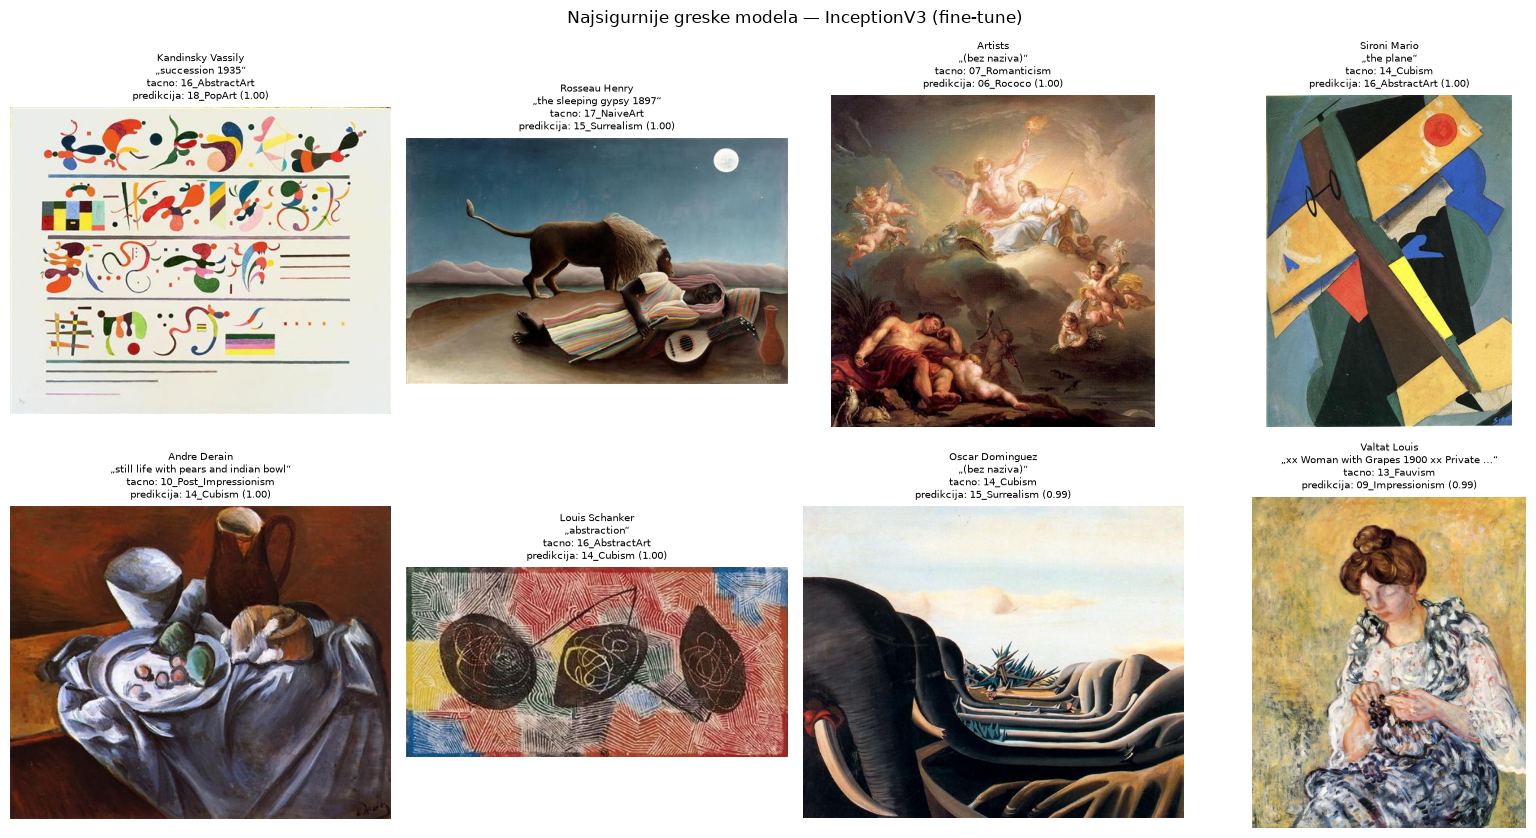

In [10]:
from PIL import Image

uzorak = errors.sort_values("sigurnost", ascending=False).head(8)

def skrati(tekst, n=38):
    return tekst if len(tekst) <= n else tekst[: n - 1] + "\u2026"

fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for ax, (_, row) in zip(axes.ravel(), uzorak.iterrows()):
    ax.imshow(Image.open(row["filepath"]).convert("RGB"))
    ax.set_title(
        f"{skrati(row['autor'], 28)}\n"
        f"\u201e{skrati(row['delo'])}\u201c\n"
        f"tacno: {row['tacna']}\n"
        f"predikcija: {row['predvidjena']} ({row['sigurnost']:.2f})",
        fontsize=7.5,
    )
    ax.axis("off")

fig.suptitle("Najsigurnije greske modela — InceptionV3 (fine-tune)")
fig.tight_layout()
fig.savefig(FIG / "transfer_finetune_errors.png", dpi=150)
plt.show()

## 5. Koliko je model siguran kad greši

Ako su greške uglavnom niske sigurnosti, model "zna da ne zna" — to je bolja greška od
samouverenog promašaja.

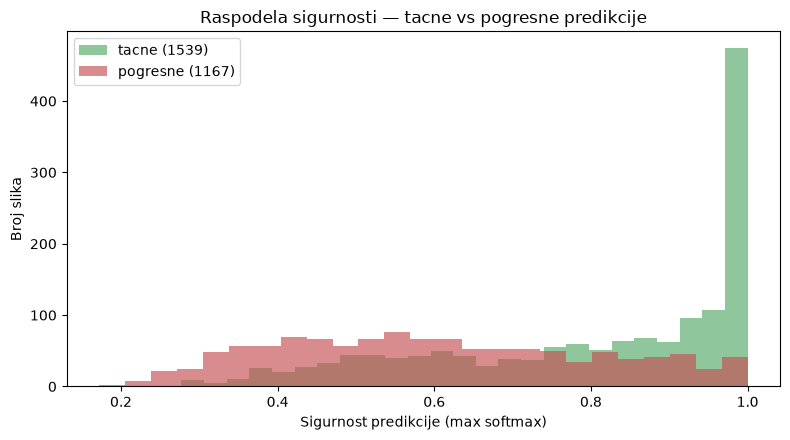

prosecna sigurnost, tacne   : 0.805
prosecna sigurnost, pogresne: 0.602
greske sa sigurnoscu > 0.9  : 114


In [11]:
tacni = confidence[y_pred == y_true]
pogresni = confidence[y_pred != y_true]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(tacni, bins=25, alpha=0.65, label=f"tacne ({len(tacni)})", color="#55A868")
ax.hist(pogresni, bins=25, alpha=0.65, label=f"pogresne ({len(pogresni)})", color="#C44E52")
ax.set_xlabel("Sigurnost predikcije (max softmax)")
ax.set_ylabel("Broj slika")
ax.set_title("Raspodela sigurnosti — tacne vs pogresne predikcije")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "transfer_finetune_confidence.png", dpi=150)
plt.show()

print("prosecna sigurnost, tacne   :", round(float(tacni.mean()), 3))
print("prosecna sigurnost, pogresne:", round(float(pogresni.mean()), 3))
print("greske sa sigurnoscu > 0.9  :", int((pogresni > 0.9).sum()))

## 6. Zaključak

**Lake klase.** Vizantijska ikonografija (recall 0.94), pop art (0.82) i rana renesansa
(0.74) — pokreti sa najizrazitijim vizuelnim potpisom: zlatna pozadina i ikonografska šema,
ravne boje i rasterski otisak, odnosno temperna paleta i zlatni oreoli.

**Teške klase.** Ekspresionizam (0.27), fovizam (0.38) i postimpresionizam (0.40). To su
pokreti koji dele paletu i motive sa susedima, pa ih razdvaja slikarski postupak, a ne
sadržaj slike — upravo ono što je ImageNet bazi najstranije.

**Greške su uglavnom razumljive.** Kod 10 najčešćih zamena prosečan razmak između klasa je
**1.4** pozicije, a **7 od 10** su neposredno susedni pokreti. Model dakle ne baca slike
nasumično po istoriji umetnosti nego greši tamo gde je granica i za čoveka sporna.

**Šta je fine-tuning promenio.** Podigao je nivo (49.9% → 56.9%) i popravio recall kod
**13 od 18 klasa**, ali **nije promenio koje su klase teške** — redosled po recall-u ostaje
skoro isti. Najveći dobitak imaju nadrealizam (+23.0) i barok (+20.3). Kod svih 5 klasa
kojima recall pada precision istovremeno raste (npr. impresionizam −0.079 recall ali +0.120
precision), što znači da je model prestao da ih koristi kao korpu za neprepoznato — F1 im
zapravo raste. Zato je macro F1 ovde pošteniji sud od recall-a po klasi.

**Model zna kad ne zna.** Prosečna sigurnost kod tačnih predikcija je **0.804**, kod
pogrešnih **0.602**. Samo **112 od 1166** grešaka ima sigurnost preko 0.9, dakle samouvereni
promašaji su manjina.

**Ograničenje.** Model se prepaja: train accuracy 0.86 naspram val 0.59, a val loss ima
minimum oko 12. epohe pa raste. Sledeći korak ne bi bio duži trening nego jača
regularizacija, više podataka po klasi ili odmrzavanje manjeg dela mreže.
